1. Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import os

# Detectar el nombre del archivo automáticamente
archivo = [f for f in os.listdir('data') if f.endswith('.csv')][0]
df = pd.read_csv(f'data/{archivo}')

print("✅ Dataset cargado")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"Archivo: {archivo}")

✅ Dataset cargado
Filas: 1200, Columnas: 14
Archivo: mening missing 12.csv


2. Vista general

In [2]:
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE VARIABLES ===")
print(df.dtypes)

numericas   = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f"\nNuméricas ({len(numericas)}): {numericas}")
print(f"Categóricas ({len(categoricas)}): {categoricas}")

=== PRIMERAS FILAS ===


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk



=== TIPOS DE VARIABLES ===
Patient_ID            int64
Age                 float64
Gender                  str
WBC_Count           float64
Protein_Level       float64
Glucose_Level       float64
Pathogen_Present        str
Diagnosis               str
Outcome                 str
Hemoglobin          float64
WBC_Blood_Count     float64
Platelets           float64
CRP_Level           float64
Risk_Level              str
dtype: object

Numéricas (9): ['Patient_ID', 'Age', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level']
Categóricas (5): ['Gender', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Risk_Level']


C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\2286637914.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


3. Valores nulos

In [3]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS ===")
print(missing[missing['Valores nulos'] > 0])
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

=== VALORES NULOS ===
                  Valores nulos  Porcentaje (%)
Hemoglobin                   19            1.58
CRP_Level                    13            1.08
Diagnosis                    12            1.00
Platelets                    12            1.00
Protein_Level                10            0.83
WBC_Blood_Count              10            0.83
Outcome                      10            0.83
Gender                        9            0.75
Glucose_Level                 8            0.67
WBC_Count                     8            0.67
Pathogen_Present              8            0.67
Age                           7            0.58

Total nulos: 126


4. Imputación

In [4]:
numericas   = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

if df.isnull().sum().sum() > 0:
    # KNN para numéricas
    imputer = KNNImputer(n_neighbors=5)
    df_num = pd.DataFrame(
        imputer.fit_transform(df[numericas]),
        columns=numericas
    )
    # Moda para categóricas
    df_cat = df[categoricas].fillna(df[categoricas].mode().iloc[0])
    df_limpio = pd.concat([df_num, df_cat], axis=1)
    print(f"✅ Imputación completada")
else:
    df_limpio = df.copy()
    print("✅ No había nulos, no se requirió imputación")

print(f"Nulos restantes: {df_limpio.isnull().sum().sum()}")

✅ Imputación completada
Nulos restantes: 0


C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\2953336599.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


5. Estadísticas descriptivas

In [5]:
df_limpio.describe().round(2)

,Patient_ID,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level
count,1200.00,1200.00,1200.00,1200.00,1200.0,1200.00,1200.00,1200.00,1200.00
mean,600.50,47.37,12131.64,109.41,52.7,9.99,11296.02,201470.72,27.47
std,346.55,24.52,5662.23,72.01,34.6,5.56,4955.44,90774.93,26.27
min,1.00,0.00,2017.00,0.00,0.0,1.00,4013.00,100204.00,0.00
25%,300.75,30.00,7007.25,43.00,26.0,5.00,6746.25,125491.25,3.00
50%,600.50,43.00,12282.00,108.50,53.0,12.00,9782.50,161347.50,25.00
75%,900.25,61.00,16884.25,167.00,66.0,15.00,15847.00,275519.00,42.00
max,1200.00,119.00,24947.00,297.00,149.0,18.00,19988.00,399110.00,99.00


6. Variable objetivo

Variable objetivo detectada: Risk_Level


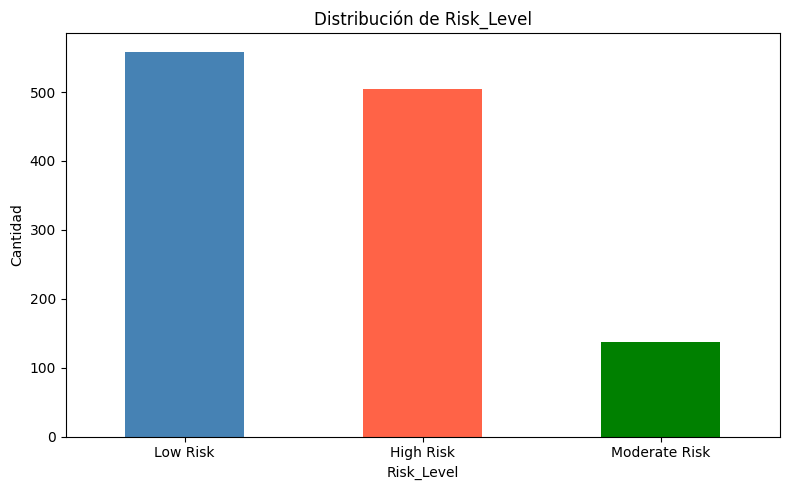

In [6]:
# Identificar la columna objetivo (diagnosis o similar)
target = categoricas[-1]  # generalmente es la última columna
print(f"Variable objetivo detectada: {target}")

plt.figure(figsize=(8, 5))
df_limpio[target].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato', 'green'])
plt.title(f'Distribución de {target}')
plt.xlabel(target)
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

7. Distribuciones de variables numéricas

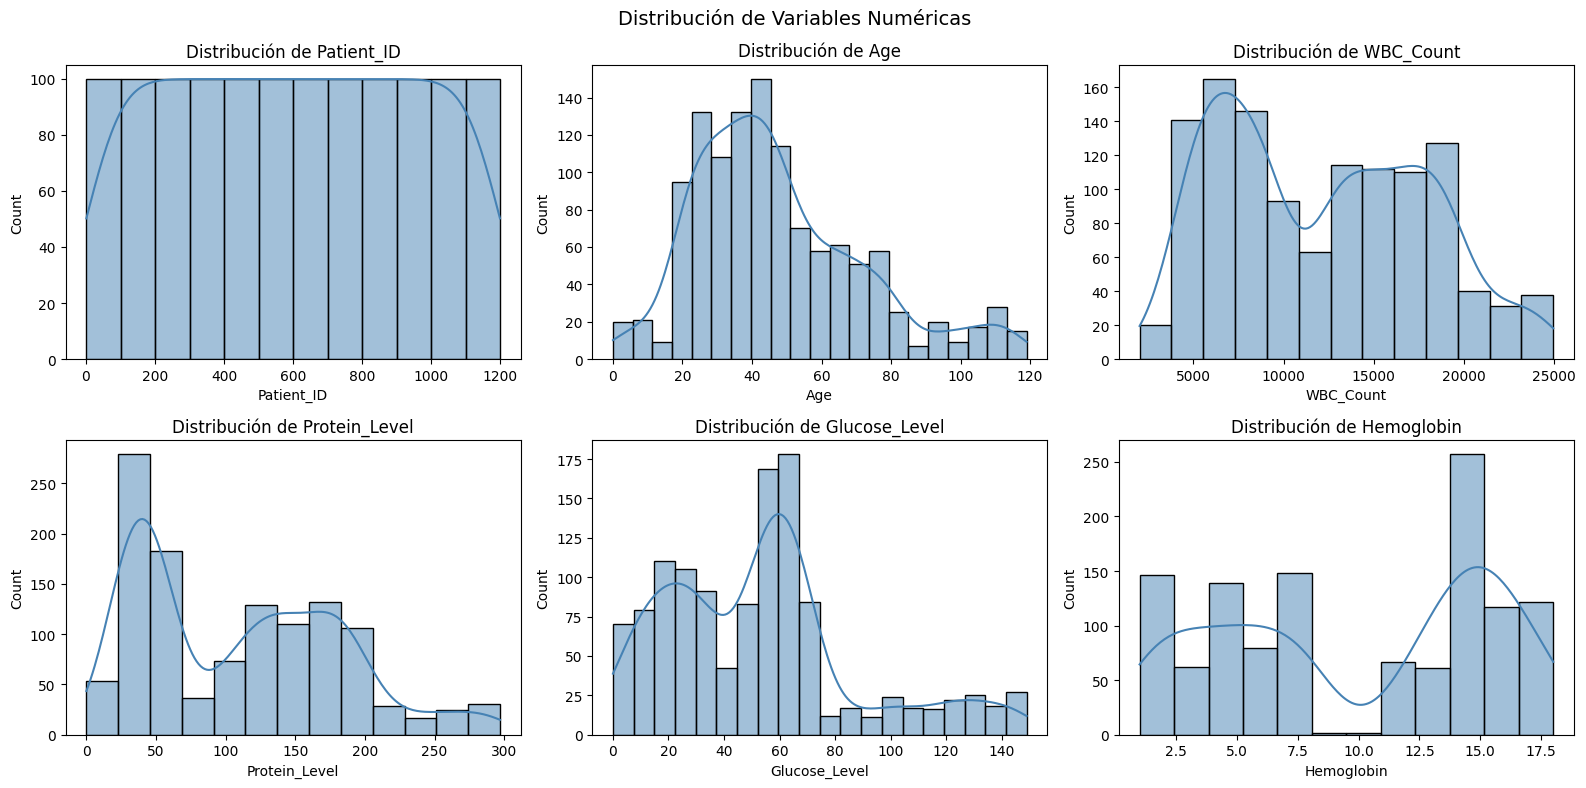

In [7]:
cols_plot = numericas[:6]  # primeras 6 numéricas

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.histplot(data=df_limpio, x=col, kde=True,
                 color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')

plt.suptitle('Distribución de Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

8. Correlaciones

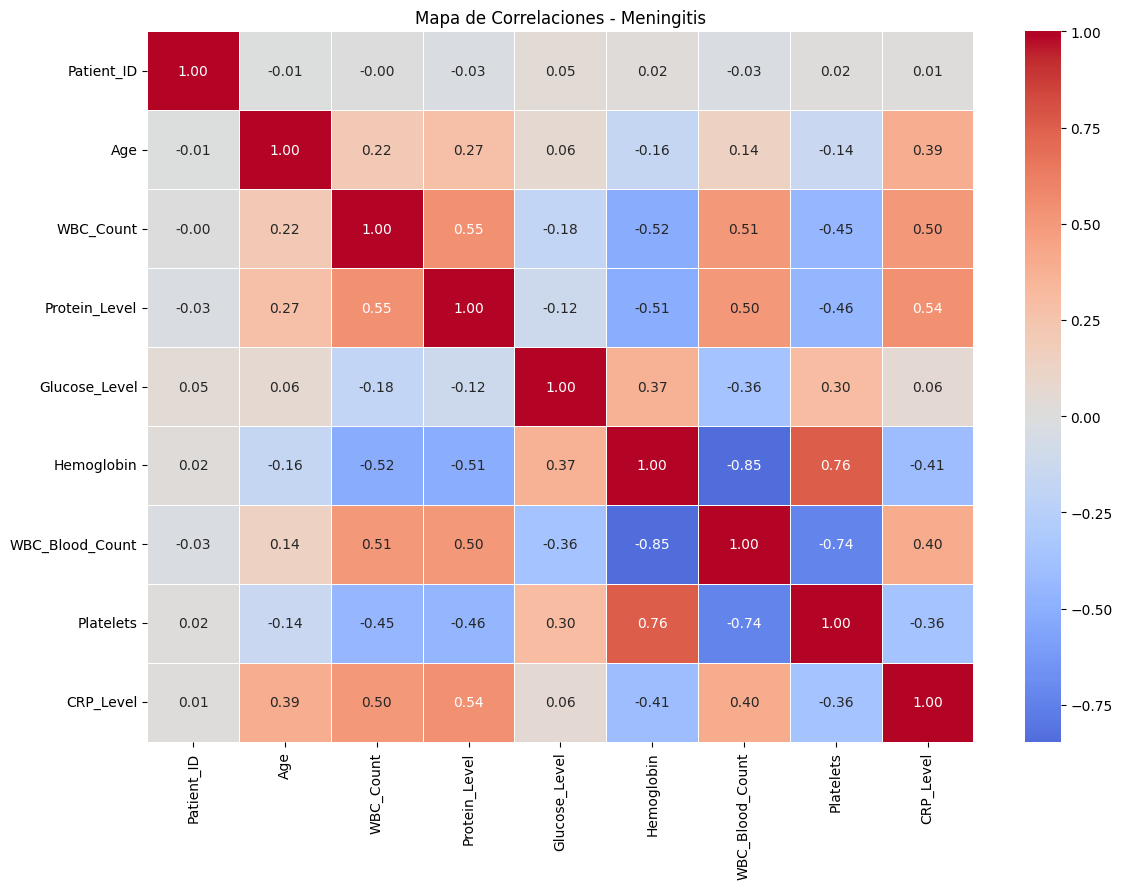

In [8]:
plt.figure(figsize=(12, 9))
corr = df_limpio[numericas].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Mapa de Correlaciones - Meningitis')
plt.tight_layout()
plt.show()

9. Boxplots por diagnóstico

C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\1360677364.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x=target, y=col,
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\1360677364.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x=target, y=col,
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\1360677364.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x=target, y=col,
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\1360677364.py:6: FutureWarning: 

Passing `palette`

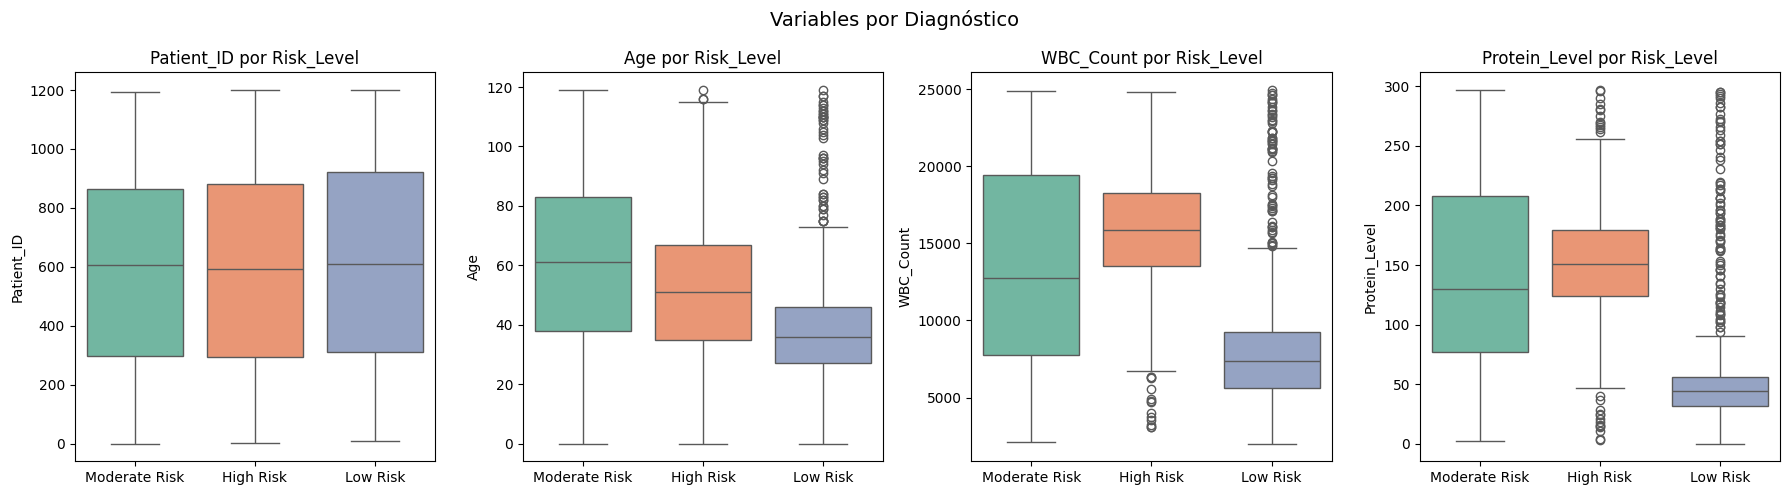

In [9]:
cols_box = numericas[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cols_box):
    sns.boxplot(data=df_limpio, x=target, y=col,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} por {target}')
    axes[i].set_xlabel('')

plt.suptitle('Variables por Diagnóstico', fontsize=14)
plt.tight_layout()
plt.show()